# Packages

In [1]:
import sys
sys.path.append('/home/boscoll/github/CDKPredict/code')
from CDKPredict_scalable import CDKPredict_scalable
import matplotlib as mpl
import pickle
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from helper_functions import *

# Data load

In [2]:
project_path = Path('/home/boscoll/Projects/cdk_predict')
train_test_split = project_path / 'data/development_cohort/train_test_split/genomic_train_test_split_msk_final'
clinical_path = project_path / 'data/development_cohort/clinical/clinical_msk_final.csv'


with open(train_test_split, 'rb') as f:
    X_genomic_train, X_genomic_test, y_train, y_test = pickle.load(f)
y_train = y_train[['Time', 'Event']].copy()

clinical = pd.read_csv(clinical_path, index_col=0)

#merged clinicogenomic
X_clinicogenomic_train = pd.concat([X_genomic_train[['TP53_tsg', 'ESR1_mut', 'RB1_tsg', 'BRCA2_tsg', 'BRCA1_tsg', 'PTEN_tsg', 'AKT1_mut', 'PIK3CA_mut']], clinical.loc[lambda x: x.index.isin(X_genomic_train.index)]], axis=1)
X_clinicogenomic_test = pd.concat([X_genomic_test[['TP53_tsg', 'ESR1_mut', 'RB1_tsg', 'BRCA2_tsg', 'BRCA1_tsg', 'PTEN_tsg', 'AKT1_mut', 'PIK3CA_mut']], clinical.loc[lambda x: x.index.isin(X_genomic_test.index)]], axis=1)
X_clinicogenomic_train = X_clinicogenomic_train.reindex(y_train.index)
X_clinicogenomic_test = X_clinicogenomic_test.reindex(y_test.index)

#from the clinical only dataframe, remove the 'met_sample' variable
X_clinical_train = clinical.loc[X_genomic_train.index].copy()
X_clinical_test = clinical.loc[X_genomic_test.index].copy()
X_clinical_train.drop(columns='met_sample', inplace=True)
X_clinical_test.drop(columns='met_sample', inplace=True)

In [3]:
palette = {'high':'#FF3030', 'intermediate':'#EEB422', 'low':'#228B22'}

# Data load

In [4]:
#clinicogenomic model
CDKPredictS_clinicogenomic = CDKPredict_scalable(
    n_models = 100, 
    l1 = 1, 
    n_folds=3, 
    bootstrap=True,
    random_state=94, 
    adaptive_lasso=True, 
    normalization = (0.01, 0.99), 
    metric = 'auc', 
    auc_time_range =(3, 36), 
)

#clinical model
CDKPredictS_clin = CDKPredict_scalable(
    n_models = 100, 
    l1 = 1, 
    n_folds=3, 
    bootstrap=True,
    random_state=94, 
    adaptive_lasso=True, 
    normalization = (0.01, 0.99), 
    metric = 'auc', 
    auc_time_range =(3, 36), 
)

In [5]:
CDKPredictS_clinicogenomic.fit(X_clinicogenomic_train, y_train)
CDKPredictS_clin.fit(X_clinical_train, y_train)

Fitting 100 base learners...
Selected `bootstrap` sampling for model fitting
Selected the option `adaptive_lasso` to assign distinct penalty to different coefficients
Using time-dependent AUC as model selection metric...
Using user-defined AUC time range for hyperparameter tuning: (3, 36)
Finished fitting 100 models.
Fitting 100 base learners...
Selected `bootstrap` sampling for model fitting
Selected the option `adaptive_lasso` to assign distinct penalty to different coefficients
Using time-dependent AUC as model selection metric...
Using user-defined AUC time range for hyperparameter tuning: (3, 36)
Finished fitting 100 models.


In [6]:
CDKPredictS_clinicogenomic.define_3_risk_groups(plot=False)
CDKPredictS_clin.define_3_risk_groups(plot=False)

cutoff between low and intermediate risk calculated at: 9.86, cutoff between intermediate and high risk calculated at: 42.21
cutoff between low and intermediate risk calculated at: 16.32, cutoff between intermediate and high risk calculated at: 62.43


In [7]:
PFS = CDKPredictS_clinicogenomic.get_train_risk_groups_3().to_frame().join(y_train)

In [8]:
PFS_test = CDKPredictS_clinicogenomic.predict(X_clinicogenomic_test, classify=True, groups = 3).to_frame().merge(y_test, left_index=True, right_index=True)
PFS_test_clin = CDKPredictS_clin.predict(X_clinical_test, classify=True, groups = 3).to_frame().merge(y_test, left_index=True, right_index=True)

Activated the classify option, returning risk groups instead of continuous risk scores.
Activated the classify option, returning risk groups instead of continuous risk scores.


**Supplementary Table 13**

In [ ]:
# ###save table for internal train
# df_save = CDKPredictS_clinicogenomic.get_train_risk_groups_3().to_frame().join(CDKPredictS_clinicogenomic.risk_scores_train).rename(columns={'risk_score':'clinicogenomic_risk_score', 'risk_group':'clinicogenomic_risk_group'})\
# .join(
# CDKPredictS_clin.get_train_risk_groups_3().to_frame().join(CDKPredictS_clin.risk_scores_train).rename(columns={'risk_score':'clinical_risk_score', 'risk_group':'clinical_risk_group'})
# ).join(y_train)
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/scalable_model_msk_train.xlsx')

In [ ]:
###save table for internal test
# df_save = CDKPredictS_clinicogenomic.predict(X_clinicogenomic_test, classify=False).to_frame().join(PFS_test).rename(columns={'risk_score':'clinicogenomic_risk_score', 'risk_group':'clinicogenomic_risk_group'})\
# .join(
#     CDKPredictS_clin.predict(X_clinical_test, classify=False).to_frame().join(PFS_test_clin).rename(columns={'risk_score':'clinical_risk_score', 'risk_group':'clinical_risk_group'}).drop(columns=['Event', 'Time'])
# )
# df_save = df_save[[col for col in df_save.columns if col not in ['Event', 'Time']] + ['Time', 'Event']]
# df_save.index = df_save.index.map(key_msk.key_col)
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/scalable_model_msk_test.xlsx')

The option `classify` is set to False, returning continuous risk scores.
Dropping extra columns in test not seen in training, n. columns: 1
The option `classify` is set to False, returning continuous risk scores.


**Fig. 6b**

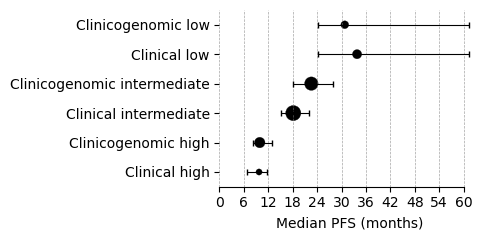

In [11]:
# clinicogenomic
# Call: survfit(formula = Surv(Time, Event) ~ risk_group, data = PFS_test)

#                     n events median 0.95LCL 0.95UCL
# risk_group=low     74     41  30.78   24.15    61.4
# risk_group=medium 186    121  22.57   18.13    27.9
# risk_group=high   120     99   9.89    8.31    13.0
# Call:
# coxph(formula = Surv(Time, Event) ~ risk_group, data = PFS_test)


#clinical
# Call: survfit(formula = Surv(Time, Event) ~ risk_group, data = PFS_test_clin)

#                     n events median 0.95LCL 0.95UCL
# risk_group=low     96     51  33.80    24.1    61.4
# risk_group=medium 231    166  18.13    15.2    22.1
# risk_group=high    53     44   9.72     6.7    11.6
# Call:
# coxph(formula = Surv(Time, Event) ~ risk_group, data = PFS_test_clin)


plot_df = pd.DataFrame({
    'Cohort': ['Clinicogenomic low', 'Clinical low', 'Clinicogenomic intermediate', 'Clinical intermediate', 'Clinicogenomic high', 'Clinical high'],
    'mPFS' : [30.78, 33.80, 22.57, 18.13, 9.89, 9.72],
    'upper_CI' : [61.4, 61.4, 27.9, 22.1, 13.0, 11.6],
    'lower_CI' : [24.15, 24.1, 18.13, 15.2, 8.31, 6.7], 
    'nr' : [74, 96, 186, 231, 120, 53]
})
plot_df = plot_df.iloc[::-1]

#forestplot with mPFS and conf int 
plt.figure(figsize=(5, 2.5))
nr_min = plot_df['nr'].min()
nr_max = plot_df['nr'].max()
plot_df['nr_normalized'] = (plot_df['nr'] - nr_min) / (nr_max - nr_min) * 100 + 20 
plt.grid(axis='x', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
plt.scatter(x=plot_df['mPFS'], y=plot_df['Cohort'], color='black', s=plot_df['nr_normalized'], marker='o', linewidths=0.2)
plt.errorbar(x=plot_df['mPFS'], y=plot_df['Cohort'], 
             xerr=[plot_df['mPFS'] - plot_df['lower_CI'], 
                    plot_df['upper_CI'] - plot_df['mPFS']], fmt='o', color='black', ecolor='black', capsize=2,
                      markersize=1.5, linewidth=0.8)

plt.xlabel('Median PFS (months)')
plt.ylabel('')
plt.xlim(0, 64)
plt.ylim(-0.5, len(plot_df)-0.5)
plt.xticks([0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60])
plt.tight_layout()
sns.despine(trim = True, left = True)
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/forest_plot_scalable_msk.pdf', bbox_inches='tight')
plt.show()


### Fine tune CDKPredict-S on the full development cohort before deployment

In [12]:
X_msk_clinicogenomic = pd.concat([X_clinicogenomic_train, X_clinicogenomic_test])
X_msk_clin = pd.concat([X_clinical_train, X_clinical_test])
y_msk = pd.concat([y_train, y_test])

In [13]:
CDKPredictS_clinicogenomic.fit(X_msk_clinicogenomic.drop(columns=['met_sample']), y_msk) 
#for IEO-CDK, met sample all missing, exclude from the deployed model, also to facilitate deployment where the sample used for sequencing many times is uknown

CDKPredictS_clin.fit(X_msk_clin, y_msk)

Fitting 100 base learners...
Selected `bootstrap` sampling for model fitting
Selected the option `adaptive_lasso` to assign distinct penalty to different coefficients
Using time-dependent AUC as model selection metric...
Using user-defined AUC time range for hyperparameter tuning: (3, 36)
Finished fitting 100 models.
Fitting 100 base learners...
Selected `bootstrap` sampling for model fitting
Selected the option `adaptive_lasso` to assign distinct penalty to different coefficients
Using time-dependent AUC as model selection metric...
Using user-defined AUC time range for hyperparameter tuning: (3, 36)
Finished fitting 100 models.


**Extended Data Fig. 9a**

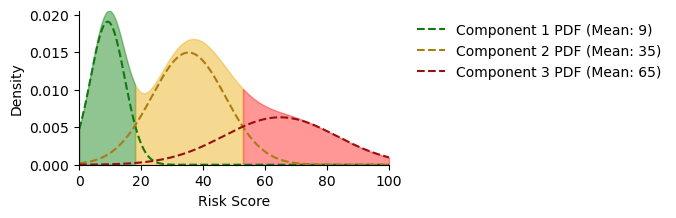

cutoff between low and intermediate risk calculated at: 18.02, cutoff between intermediate and high risk calculated at: 52.79


In [17]:
CDKPredictS_clin.define_3_risk_groups(plot=True, legend=True, bins = 20, figsize=(4, 2), detailed = False, 
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/risk_groups_clinical_msk.pdf'
                                    )

In [ ]:
# CDKPredictS_clin.save_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinical_final.pkl')

Model saved to /home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinical_final.pkl


**Extended Data Fig. 9b**

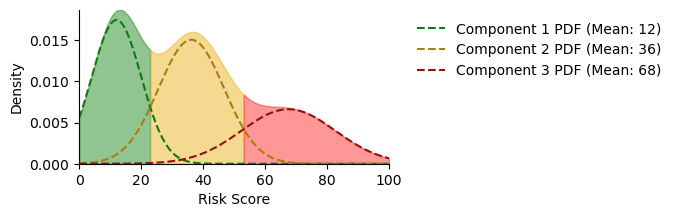

cutoff between low and intermediate risk calculated at: 22.90, cutoff between intermediate and high risk calculated at: 53.09


In [19]:
CDKPredictS_clinicogenomic.define_3_risk_groups(plot=True, legend=True, bins = 30, figsize=(4, 2), detailed = False, 
# save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/risk_groups_clinicogenomic_msk.pdf'
)

In [ ]:
# CDKPredictS_clinicogenomic.save_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinicogenomic_final.pkl')

Model saved to /home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinicogenomic_final.pkl


## External multi-Institutional cohort

In [78]:
###Cohorts
X_tempus = pd.read_csv('/scratch/razavip/boscoll/cdk_predict/data/tempus_cohort/genomics/X_tempus_31Jan_2026.csv', index_col=0)
X_tempus_clin = pd.read_csv('/scratch/razavip/boscoll/cdk_predict/data/tempus_cohort/clinical/X_tempus_clinical_29Jan_2026.csv', index_col=0)
y_tempus = pd.read_csv('/scratch/razavip/boscoll/cdk_predict/data/tempus_cohort/clinical/y_tempus_26Jan_2026.csv', index_col=0)
X_tempus_clinicogenomic = pd.concat([X_tempus, X_tempus_clin], axis=1)

In [79]:
PFS_tempus = min_model.predict(X_tempus_clinicogenomic, classify=True, groups = 3).to_frame().join(y_tempus)

Dropping extra columns in test not seen in training, n. columns: 375
Activated the classify option, returning risk groups instead of continuous risk scores.


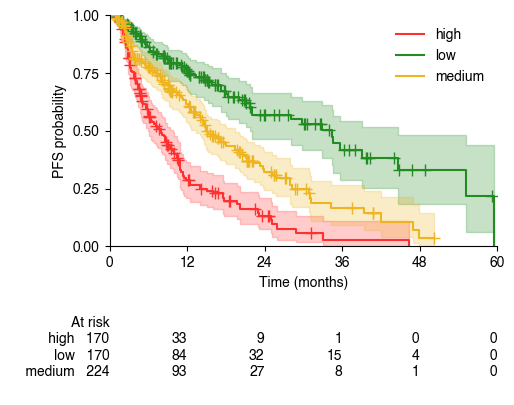

In [80]:
PFS_tempus.pipe(plot_kaplan_meier_risktable, 'risk_group', colors = palette, conf_intervals = True,  upper_limit=60, figsize=(5,3), only_risk = True,
         ylabel = 'PFS probability',
        #   save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/tempus/KM_cinicogenomic_tempus.pdf'         
         )

In [ ]:
%%R -i PFS_tempus
PFS_tempus$risk_group = factor(PFS_tempus$risk_group, levels = c('low', 'medium', 'high'))
print(survfit(Surv(Time, Event) ~ risk_group, data = PFS_tempus))
summary(coxph(Surv(Time, Event) ~ risk_group, data = PFS_tempus))


Call: survfit(formula = Surv(Time, Event) ~ risk_group, data = PFS_tempus)



                    n events median 0.95LCL 0.95UCL
risk_group=low    170     59  34.39   22.09      NA
risk_group=medium 224    121  15.09   13.45   20.12
risk_group=high   170    123   7.99    6.08    9.96
Call:
coxph(formula = Surv(Time, Event) ~ risk_group, data = PFS_tempus)

  n= 564, number of events= 303 

                   coef exp(coef) se(coef)     z Pr(>|z|)    
risk_groupmedium 0.7203    2.0550   0.1617 4.455 8.39e-06 ***
risk_grouphigh   1.4201    4.1374   0.1644 8.638  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                 exp(coef) exp(-coef) lower .95 upper .95
risk_groupmedium     2.055     0.4866     1.497     2.821
risk_grouphigh       4.137     0.2417     2.998     5.710

Concordance= 0.637  (se = 0.016 )
Likelihood ratio test= 82.15  on 2 df,   p=<2e-16
Wald test            = 78.52  on 2 df,   p=<2e-16
Score (logrank) test = 86.75  on 2 df,   p=<2e-16



## IEO

In [123]:
#clinical 
clinical_ieo = pd.read_excel('/scratch/razavip/boscoll/cdk_predict/data/ieo_cohort/DB_MultimodalCDK46_29Apr.xlsx', sheet_name=0, index_col=0)
clinical_ieo.columns = clinical_ieo.columns.str.replace('/', '_', regex=False)
clinical_ieo = clinical_ieo.query('line_CDK4_6 == 1')
clinical_ieo['Event'] = (clinical_ieo.reason_discontinuation == 1).astype(int)
clinical_ieo['Time'] = calculate_months(clinical_ieo, 'CDK4_6_start', 'CDK4_6_end (or last for ongoing)')
clinical_ieo = clinical_ieo.query('Time > 1')
y_ieo = clinical_ieo[['Event', 'Time']]
clinical_ieo = clinical_ieo.fillna(0) #tfi is recorded as missing for de novo patients, code as 0

In [124]:
#genomics
genomics_ieo = pd.read_excel('/scratch/razavip/boscoll/cdk_predict/data/ieo_cohort/DB_MultimodalCDK46_29Apr.xlsx', sheet_name=1, index_col=0)
genomics_ieo['genomics'] = [0 if i in ['CC09020341', 'CC11007059'] else genomics for i, genomics in zip(genomics_ieo.index, genomics_ieo['genomics'])]
genomics_ieo = genomics_ieo.query('genomics == 1')
# genomics_ieo.fillna(0, inplace=True)
genomics_ieo = genomics_ieo.query('index in @y_ieo.index')

In [125]:
#EXCLUDE IEO PATIENTS WITHOUT CONSENT FOR RESEARCH
keys = pd.read_excel('/scratch/razavip/boscoll/cdk_predict/data/ieo_cohort/DB_MultimodalCDK46 - Key ID.xlsx', index_col=0)
clinical_ieo.index = clinical_ieo.index.map(keys['Study_ID'])
y_ieo.index = y_ieo.index.map(keys['Study_ID'])
genomics_ieo.index = genomics_ieo.index.map(keys['Study_ID'])

#ids to exclude --> ieo_multimodal_cdk_0036, ieo_multimodal_cdk_0067, ieo_multimodal_cdk_0160, ieo_multimodal_cdk_0192, ieo_multimodal_cdk_0240, ieo_multimodal_cdk_0356, ieo_multimodal_cdk_0556
ids_to_exclude = ['ieo_multimodal_cdk_0036', 'ieo_multimodal_cdk_0067', 'ieo_multimodal_cdk_0160', 'ieo_multimodal_cdk_0192', 'ieo_multimodal_cdk_0240', 'ieo_multimodal_cdk_0356', 'ieo_multimodal_cdk_0556']

clinical_ieo = clinical_ieo.query('index not in @ids_to_exclude')
y_ieo = y_ieo.query('index not in @ids_to_exclude')
genomics_ieo = genomics_ieo.query('index not in @ids_to_exclude')

In [126]:
ieo_clinicogenomic = clinical_ieo.join(genomics_ieo, how='inner')
ieo_clinicogenomic_full = clinical_ieo.join(genomics_ieo, how='outer')

print(f'number of patients in clinicogenomic cohort: {ieo_clinicogenomic.shape[0]}')
print(f'number of patients in clinicogenomic full cohort: {ieo_clinicogenomic_full.shape[0]}')

number of patients in clinicogenomic cohort: 96
number of patients in clinicogenomic full cohort: 455


In [127]:
# PFS_ieo = min_model.predict(ieo_clinicogenomic_full, classify=True, groups = 3).to_frame().join(y_ieo)
PFS_ieo_clinicogenomic = min_model.predict(ieo_clinicogenomic, classify=True, groups = 3).to_frame().join(y_ieo)
PFS_ieo_clinical = min_model_clin.predict(ieo_clinicogenomic_full.query('index not in @ieo_clinicogenomic.index'), classify=True, groups = 3).to_frame().join(y_ieo)
PFS_ieo = pd.concat([PFS_ieo_clinicogenomic, PFS_ieo_clinical])


Dropping extra columns in test not seen in training, n. columns: 50
Activated the classify option, returning risk groups instead of continuous risk scores.
Dropping extra columns in test not seen in training, n. columns: 58
Activated the classify option, returning risk groups instead of continuous risk scores.


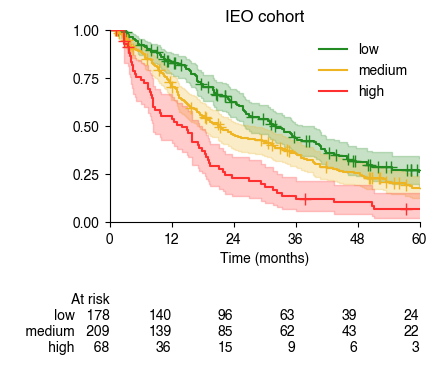

In [128]:
#on full cohort with or without available genomic data
PFS_ieo.pipe(plot_kaplan_meier_risktable, 'risk_group', colors = palette, conf_intervals = True, title = 'IEO cohort', upper_limit=60, figsize=(4, 2.5), only_risk=True
        #  save = ''
         )

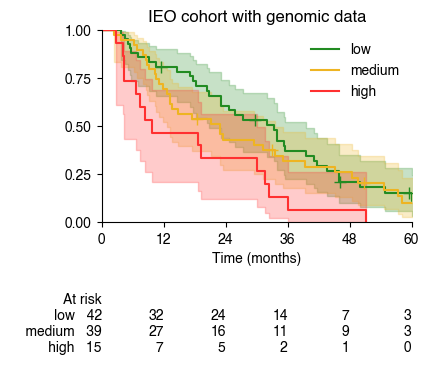

In [88]:
PFS_ieo.query('index in @ieo_clinicogenomic.index').pipe(plot_kaplan_meier_risktable, 'risk_group', colors = palette, conf_intervals = True, title = 'IEO cohort with genomic data', upper_limit=60, figsize=(4, 2.5), only_risk=True
        #  save = ''
         )

In [129]:
PFS_ieo_clinicogenomic = PFS_ieo.query('index in @ieo_clinicogenomic.index')

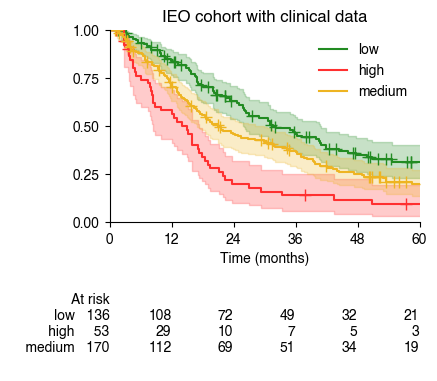

In [90]:
PFS_ieo.query('index not in @ieo_clinicogenomic.index').pipe(plot_kaplan_meier_risktable, 'risk_group', colors = palette, conf_intervals = True, title = 'IEO cohort with clinical data', upper_limit=60, figsize=(4, 2.5), only_risk=True
        #  save = ''
         )

## Pooled cohort

In [131]:
#concatenate ieo and tempus
PFS_combined = pd.concat([PFS_ieo.assign(cohort='ieo'), PFS_tempus.assign(cohort='tempus')])
print(f'nr of patients in the pooled external cohort: {PFS_combined.shape[0]}')

nr of patients in the pooled external cohort: 1019


In [132]:
#risk scores
risk_scores_IEO = min_model.predict(ieo_clinicogenomic_full, verbose=False).reindex(PFS_ieo.index)
risk_scores_tempus = min_model.predict(X_tempus_clinicogenomic, verbose=False).reindex(PFS_tempus.index)
PFS_combined = pd.concat([risk_scores_IEO, risk_scores_tempus]).to_frame().join(PFS_combined)

## Divide clinical only and genomic only

***Clinicogenomic cohort***

In [142]:
clinicogenomic_cohort = PFS_combined.query('index in @ieo_clinicogenomic.index or index in @X_tempus_clinicogenomic.index')
print(f'number of patients in the clinicogenomic cohort: {clinicogenomic_cohort.shape[0]}')
# clinicogenomic_cohort['risk_group'] = pd.Categorical(clinicogenomic_cohort['risk_group'], categories=['low', 'medium', 'high'], ordered=True)


number of patients in the clinicogenomic cohort: 660


In [146]:
key_external_validation = pd.concat([key_ieo.reset_index().set_index('Study_ID')['key_col'], key_ext])

In [ ]:
# ###save table for external validation
# df_save = clinicogenomic_cohort.drop(columns=['cohort'])
# df_save.index = df_save.index.map(key_external_validation.key_col)
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/clinicogenomic_scalable_model_external_validation.xlsx')

In [152]:
clinicogenomic_cohort.risk_group.value_counts(normalize=True)

risk_group
medium    0.398485
low       0.321212
high      0.280303
Name: proportion, dtype: float64

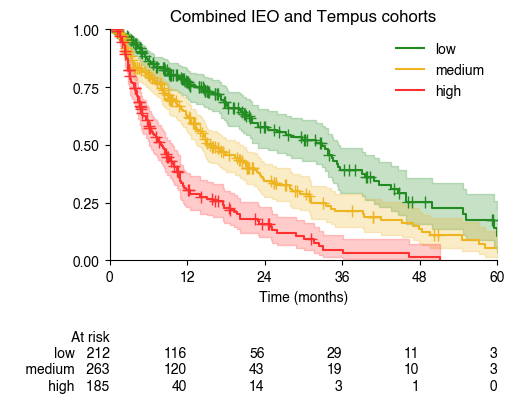

In [ ]:
plot_kaplan_meier_risktable(clinicogenomic_cohort, 'risk_group', colors = palette, conf_intervals = True, title = 'Combined IEO and Tempus cohorts', upper_limit=60, figsize=(5,3), only_risk=True,
        #  save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/combined_external_cohort_km.pdf'
         )


In [ ]:
%%R -i clinicogenomic_cohort
#high vs low HR
clinicogenomic_cohort$risk_group = factor(clinicogenomic_cohort$risk_group, levels = c('low','high', 'medium'))
print(survfit(Surv(Time, Event) ~ risk_group, data = clinicogenomic_cohort))
print(summary(coxph(Surv(Time, Event) ~ risk_group, data = clinicogenomic_cohort)))

#exact p value
print(summary(coxph(Surv(Time, Event) ~ risk_group, data = clinicogenomic_cohort))$coefficients[, 5])


Call: survfit(formula = Surv(Time, Event) ~ risk_group, data = clinicogenomic_cohort)

                    n events median 0.95LCL 0.95UCL
risk_group=low    212     96  32.94   23.06   39.05
risk_group=high   185    138   8.05    6.38    9.96
risk_group=medium 263    155  15.22   14.00   20.71


Call:
coxph(formula = Surv(Time, Event) ~ risk_group, data = clinicogenomic_cohort)

  n= 660, number of events= 389 

                   coef exp(coef) se(coef)     z Pr(>|z|)    
risk_grouphigh   1.2817    3.6028   0.1374 9.328  < 2e-16 ***
risk_groupmedium 0.5291    1.6975   0.1305 4.054 5.03e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                 exp(coef) exp(-coef) lower .95 upper .95
risk_grouphigh       3.603     0.2776     2.752     4.716
risk_groupmedium     1.697     0.5891     1.314     2.192

Concordance= 0.638  (se = 0.015 )
Likelihood ratio test= 88.58  on 2 df,   p=<2e-16
Wald test            = 90.89  on 2 df,   p=<2e-16
Score (logrank) test = 98.85  on 2 df,   p=<2e-16

  risk_grouphigh risk_groupmedium 
    1.081141e-20     5.025917e-05 


In [ ]:
%%R -i clinicogenomic_cohort
#high vs medium HR
clinicogenomic_cohort$risk_group = factor(clinicogenomic_cohort$risk_group, levels = c('medium', 'low','high'))
print(summary(coxph(Surv(Time, Event) ~ risk_group, data = clinicogenomic_cohort)))

#exact p value
print(summary(coxph(Surv(Time, Event) ~ risk_group, data = clinicogenomic_cohort))$coefficients[, 5])


Call:
coxph(formula = Surv(Time, Event) ~ risk_group, data = clinicogenomic_cohort)

  n= 660, number of events= 389 

                  coef exp(coef) se(coef)      z Pr(>|z|)    
risk_grouplow  -0.5291    0.5891   0.1305 -4.054 5.03e-05 ***


risk_grouphigh  0.7526    2.1224   0.1195  6.298 3.02e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

               exp(coef) exp(-coef) lower .95 upper .95
risk_grouplow     0.5891     1.6975    0.4561    0.7608
risk_grouphigh    2.1224     0.4712    1.6792    2.6826

Concordance= 0.638  (se = 0.015 )
Likelihood ratio test= 88.58  on 2 df,   p=<2e-16
Wald test            = 90.89  on 2 df,   p=<2e-16
Score (logrank) test = 98.85  on 2 df,   p=<2e-16

 risk_grouplow risk_grouphigh 
  5.025917e-05   3.023722e-10 


In [ ]:
#risk scores
risk_scores_IEO = min_model.predict(ieo_clinicogenomic, verbose=False).reindex(PFS_ieo.query('index in @ieo_clinicogenomic.index').index)
risk_scores_tempus = min_model.predict(X_tempus_clinicogenomic, verbose=False).reindex(PFS_tempus.index)
risk_scores_clinicogenomic = pd.concat([risk_scores_IEO, risk_scores_tempus]).to_frame().join(PFS_combined[['Time', 'Event']])

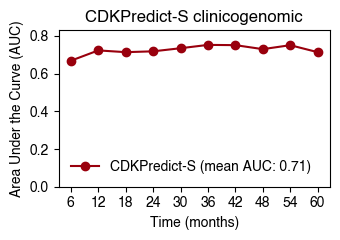

In [ ]:
plot_time_dependent_auc_from_scores([risk_scores_clinicogenomic['risk_score'].values], 
                                    ['CDKPredict-S'], 
                                    y_forSurv(y_train), 
                                    y_forSurv(risk_scores_clinicogenomic[['Event', 'Time']]), 
                                    grid = False,
                                    times=np.arange(6, 61, 6), 
                                    figsize=(3.5,2.5),
                                    ylim=(0, 0.83), 
                                    palette = {'CDKPredict-S': '#99000d'},
                                    title = 'CDKPredict-S clinicogenomic', 
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/auc_scalable_clinicogenomic.pdf'
                                    )

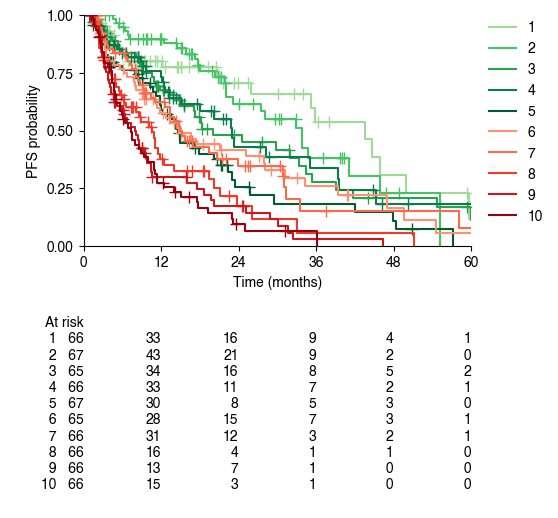

In [ ]:
risk_scores_clinicogenomic['risk_bin'] = pd.qcut(risk_scores_clinicogenomic['risk_score'], q=10, labels=False)
risk_scores_clinicogenomic['risk_bin'] = risk_scores_clinicogenomic['risk_bin'] + 1
risk_scores_clinicogenomic = risk_scores_clinicogenomic.sort_values('risk_bin')
palette_km = {10:'#99000d', 9:'#cb181d', 8:'#ef3b2c', 7:'#fb6a4a', 6:'#fc9272', 5:'#005a32', 4:"#0B7C49", 3:"#2aa051", 2:"#44c366", 1:'#a1d99b'}
plot_kaplan_meier_risktable(risk_scores_clinicogenomic, 'risk_bin', colors=palette_km, figsize=(5,3), conf_intervals=False, only_risk=True, legend_out=True, upper_limit=60,
                            ylabel = 'PFS probability',
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/risk_bin_clinicogenomic.pdf'
                            )


***Clinical cohort***

In [155]:
clinical_cohort = pd.concat(
    [
min_model_clin.predict(X_tempus_clinicogenomic, classify=True, groups = 3).to_frame().join(y_tempus), 
min_model_clin.predict(ieo_clinicogenomic_full, classify=True, groups = 3).to_frame().join(y_ieo)
    ]
)
# clinical_cohort['risk_group'] = pd.Categorical(clinical_cohort['risk_group'], categories=['low', 'medium', 'high'], ordered=True)
clinical_cohort = clinical_cohort.sort_values('risk_group')
print(f'number of patients in the clinical cohort: {clinical_cohort.shape[0]}')

Dropping extra columns in test not seen in training, n. columns: 383
Activated the classify option, returning risk groups instead of continuous risk scores.
Dropping extra columns in test not seen in training, n. columns: 58
Activated the classify option, returning risk groups instead of continuous risk scores.
number of patients in the clinical cohort: 1019


In [ ]:
clinical_cohort.risk_group.value_counts(normalize=True)

risk_group
medium    0.433759
low       0.339549
high      0.226693
Name: proportion, dtype: float64

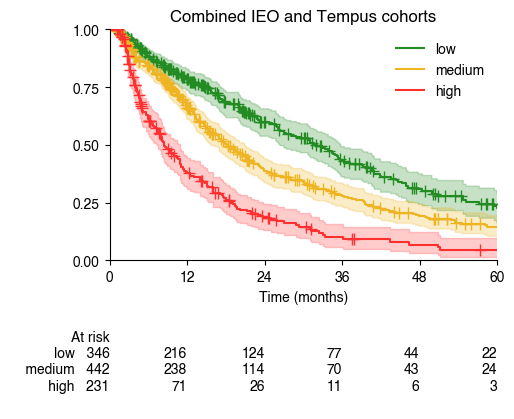

In [ ]:
clinical_cohort['risk_group'] = pd.Categorical(clinical_cohort['risk_group'], categories=['low', 'medium', 'high'], ordered=True)
clinical_cohort = clinical_cohort.sort_values('risk_group')

plot_kaplan_meier_risktable(clinical_cohort, 'risk_group', colors = palette, conf_intervals = True, title = 'Combined IEO and Tempus cohorts', upper_limit=60, figsize=(5,3), only_risk=True,
        #  save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/combined_cohort_clinical.pdf'
         )

clinical_cohort['risk_group'] = clinical_cohort['risk_group'].astype(str)


In [ ]:
%%R -i clinical_cohort
#high vs low HR
clinical_cohort$risk_group = factor(clinical_cohort$risk_group, levels = c('low', 'medium', 'high'))
print(survfit(Surv(Time, Event) ~ risk_group, data = clinical_cohort))
print(summary(coxph(Surv(Time, Event) ~ risk_group, data = clinical_cohort)))

#exact p value
print(summary(coxph(Surv(Time, Event) ~ risk_group, data = clinical_cohort))$coefficients[, 5])


Call: survfit(formula = Surv(Time, Event) ~ risk_group, data = clinical_cohort)

                    n events median 0.95LCL 0.95UCL
risk_group=low    346    176  32.00   27.00    35.8
risk_group=medium 442    291  18.17   16.36    21.1
risk_group=high   231    176   8.48    7.49    11.0
Call:


coxph(formula = Surv(Time, Event) ~ risk_group, data = clinical_cohort)

  n= 1019, number of events= 643 

                    coef exp(coef) se(coef)      z Pr(>|z|)    
risk_groupmedium 0.43894   1.55106  0.09565  4.589 4.45e-06 ***
risk_grouphigh   1.12827   3.09032  0.10844 10.404  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                 exp(coef) exp(-coef) lower .95 upper .95
risk_groupmedium     1.551     0.6447     1.286     1.871
risk_grouphigh       3.090     0.3236     2.499     3.822

Concordance= 0.621  (se = 0.012 )
Likelihood ratio test= 103.6  on 2 df,   p=<2e-16
Wald test            = 110.4  on 2 df,   p=<2e-16
Score (logrank) test = 118  on 2 df,   p=<2e-16

risk_groupmedium   risk_grouphigh 
    4.453591e-06     2.371744e-25 


In [ ]:
%%R -i clinical_cohort
#high vs medium HR
clinical_cohort$risk_group = factor(clinical_cohort$risk_group, levels = c('medium', 'high', 'low'))
print(survfit(Surv(Time, Event) ~ risk_group, data = clinical_cohort))
print(summary(coxph(Surv(Time, Event) ~ risk_group, data = clinical_cohort)))

#exact p value
print(summary(coxph(Surv(Time, Event) ~ risk_group, data = clinical_cohort))$coefficients[, 5])


Call: survfit(formula = Surv(Time, Event) ~ risk_group, data = clinical_cohort)

                    n events median 0.95LCL 0.95UCL
risk_group=medium 442    291  18.17   16.36    21.1
risk_group=high   231    176   8.48    7.49    11.0
risk_group=low    346    176  32.00   27.00    35.8


Call:
coxph(formula = Surv(Time, Event) ~ risk_group, data = clinical_cohort)

  n= 1019, number of events= 643 

                   coef exp(coef) se(coef)      z Pr(>|z|)    
risk_grouphigh  0.68934   1.99240  0.09667  7.131 9.95e-13 ***
risk_grouplow  -0.43894   0.64472  0.09565 -4.589 4.45e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

               exp(coef) exp(-coef) lower .95 upper .95
risk_grouphigh    1.9924     0.5019    1.6485    2.4080
risk_grouplow     0.6447     1.5511    0.5345    0.7777

Concordance= 0.621  (se = 0.012 )
Likelihood ratio test= 103.6  on 2 df,   p=<2e-16
Wald test            = 110.4  on 2 df,   p=<2e-16
Score (logrank) test = 118  on 2 df,   p=<2e-16

risk_grouphigh  risk_grouplow 
  9.950876e-13   4.453591e-06 


In [157]:
#risk scores
risk_scores_IEO = min_model_clin.predict(ieo_clinicogenomic_full, verbose=False).reindex(PFS_ieo.query('index in @ieo_clinicogenomic_full.index').index)
risk_scores_tempus = min_model_clin.predict(X_tempus_clinicogenomic, verbose=False).reindex(PFS_tempus.index)
risk_scores_clinical = pd.concat([risk_scores_IEO, risk_scores_tempus]).to_frame().join(PFS_combined[['Time', 'Event']])

In [ ]:
# ###save table for external validation
# df_save = risk_scores_clinical.drop(columns=['Time', 'Event']).join(clinical_cohort)
# df_save.index = df_save.index.map(key_external_validation.key_col)
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/clinical_scalable_model_external_validation.xlsx')

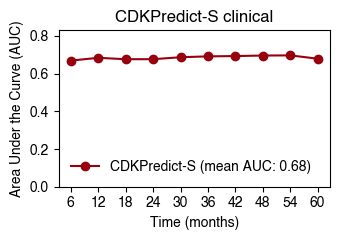

In [162]:
plot_time_dependent_auc_from_scores([risk_scores_clinical['risk_score'].values], 
                                    ['CDKPredict-S'], 
                                    y_forSurv(y_train), 
                                    y_forSurv(risk_scores_clinical[['Event', 'Time']]), 
                                    grid = False,
                                    times=np.arange(6, 61, 6), 
                                    figsize=(3.5,2.5),
                                    ylim=(0, 0.83), 
                                    palette = {'CDKPredict-S': '#99000d'},
                                    title = 'CDKPredict-S clinical', 
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/auc_scalable_clinical.pdf'
                                    )

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


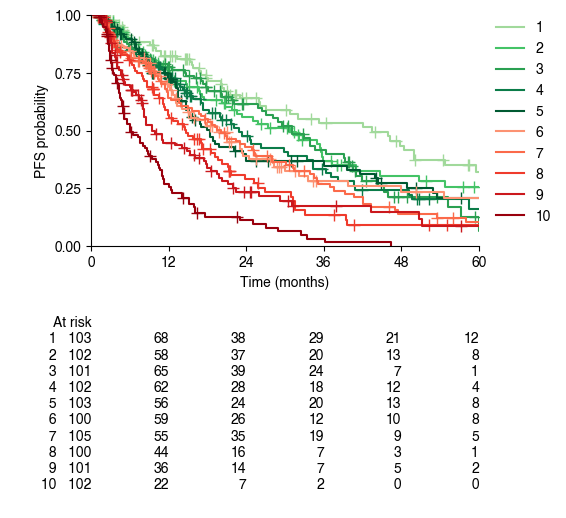

In [ ]:
risk_scores_clinical['risk_bin'] = pd.qcut(risk_scores_clinical['risk_score'], q=10, labels=False)
risk_scores_clinical['risk_bin'] = risk_scores_clinical['risk_bin'] + 1
risk_scores_clinical = risk_scores_clinical.sort_values('risk_bin')
palette_km = {10:'#99000d', 9:'#cb181d', 8:'#ef3b2c', 7:'#fb6a4a', 6:'#fc9272', 5:'#005a32', 4:"#0B7C49", 3:"#2aa051", 2:"#44c366", 1:'#a1d99b'}
plot_kaplan_meier_risktable(risk_scores_clinical, 'risk_bin', colors=palette_km, figsize=(5,3), conf_intervals=False, only_risk=True, legend_out=True, upper_limit=60,
                            ylabel = 'PFS probability',
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/risk_bin_clinical.pdf'
                            )


In [ ]:
#put all columns as 0
simulation = pd.DataFrame(0, columns=X_train_clingen.columns, index=range(1))


In [ ]:
print(min_model.predict(simulation))
simulation['TP53_tsg'] = 1
print(min_model.predict(simulation))
simulation['TP53_tsg'] = np.nan
print(min_model.predict(simulation))

The option `classify` is set to False, returning continuous risk scores.
index
0    3.138769
Name: risk_score, dtype: float64
The option `classify` is set to False, returning continuous risk scores.
index
0    27.104015
Name: risk_score, dtype: float64
The option `classify` is set to False, returning continuous risk scores.
index
0    9.262799
Name: risk_score, dtype: float64
